In [70]:
import pandas as pd 
import seaborn as sns 
import matplotlib.pyplot as plt 
import scipy.stats as st


In [71]:
df_users_2017 = pd.read_csv('acc2017/usagers-2017.csv', encoding='latin-1')
df_acc_2017 = pd.read_csv('acc2017/caracteristiques-2017.csv', encoding='latin-1')
df_users_2018 = pd.read_csv('acc-data/ACC-usagers-2018.csv')
df_acc_2018 = pd.read_csv("acc-data/ACC-caracteristiques-2018.csv")

merge_2017 = df_acc_2017.merge(df_users_2017, "inner", on="Num_Acc")
merge_2018 = df_acc_2018.merge(df_users_2018, "inner", on="Num_Acc")

In [72]:
merge = pd.concat([merge_2017, merge_2018], ignore_index=True)
merge

,Num_Acc,an,mois,jour,hrmn,lum,agg,int,atm,col,...,catu,grav,sexe,trajet,secu,locp,actp,etatp,an_nais,num_veh
0,201700000001,17,1,11,1820,5,2,1,1.0,1.0,...,1,3,1,9.0,13.0,0.0,0.0,0.0,1968.0,B01
1,201700000001,17,1,11,1820,5,2,1,1.0,1.0,...,2,3,2,9.0,11.0,0.0,0.0,0.0,1973.0,B01
2,201700000001,17,1,11,1820,5,2,1,1.0,1.0,...,1,3,1,1.0,13.0,0.0,0.0,0.0,1967.0,A01
3,201700000002,17,2,13,1630,1,2,3,1.0,3.0,...,1,1,1,0.0,11.0,0.0,0.0,0.0,1953.0,A01
4,201700000002,17,2,13,1630,1,2,3,1.0,3.0,...,1,3,1,5.0,22.0,0.0,0.0,0.0,1960.0,B01
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
266185,201800057781,18,12,22,2150,5,2,1,1.0,6.0,...,3,4,1,9.0,3.0,4.0,3.0,1.0,1975.0,A01
266186,201800057782,18,12,23,1945,5,2,1,1.0,1.0,...,1,4,2,9.0,11.0,NaN,NaN,NaN,1993.0,A01
266187,201800057782,18,12,23,1945,5,2,1,1.0,1.0,...,1,4,1,9.0,21.0,NaN,NaN,NaN,1974.0,B01
266188,201800057783,18,12,28,1425,1,2,1,1.0,1.0,...,1,4,1,9.0,11.0,NaN,NaN,NaN,1973.0,B01


In [73]:
df_time = merge[["Num_Acc","hrmn","lum","grav","dep"]]
df_time

,Num_Acc,hrmn,lum,grav,dep
0,201700000001,1820,5,3,590
1,201700000001,1820,5,3,590
2,201700000001,1820,5,3,590
3,201700000002,1630,1,1,590
4,201700000002,1630,1,3,590
...,...,...,...,...,...
266185,201800057781,2150,5,4,976
266186,201800057782,1945,5,4,976
266187,201800057782,1945,5,4,976
266188,201800057783,1425,1,4,976


In [74]:
df_time["hr"] = df_time["hrmn"]
df_time

,Num_Acc,hrmn,lum,grav,dep,hr
0,201700000001,1820,5,3,590,1820
1,201700000001,1820,5,3,590,1820
2,201700000001,1820,5,3,590,1820
3,201700000002,1630,1,1,590,1630
4,201700000002,1630,1,3,590,1630
...,...,...,...,...,...,...
266185,201800057781,2150,5,4,976,2150
266186,201800057782,1945,5,4,976,1945
266187,201800057782,1945,5,4,976,1945
266188,201800057783,1425,1,4,976,1425


In [75]:
def change(x):
    if x == 2:
        return 4
    if x == 4:
        return 2
    if x == 1:
        return 1 
    if x == 3:
        return 3

In [76]:
df_time["grav1"] = df_time["grav"].map(change)
df_time

,Num_Acc,hrmn,lum,grav,dep,hr,grav1
0,201700000001,1820,5,3,590,1820,3
1,201700000001,1820,5,3,590,1820,3
2,201700000001,1820,5,3,590,1820,3
3,201700000002,1630,1,1,590,1630,1
4,201700000002,1630,1,3,590,1630,3
...,...,...,...,...,...,...,...
266185,201800057781,2150,5,4,976,2150,2
266186,201800057782,1945,5,4,976,1945,2
266187,201800057782,1945,5,4,976,1945,2
266188,201800057783,1425,1,4,976,1425,2


In [77]:
time_paris = df_time[df_time["dep"] == 750]
time_lyon = df_time[df_time["dep"] == 690]

In [78]:
time_lyon['hr'] = (time_lyon["hrmn"]/100).astype(int)
time_paris['hr'] = (time_paris["hrmn"]/100).astype(int)

time_lyon

,Num_Acc,hrmn,lum,grav,dep,hr,grav1
4062,201700001776,1730,5,1,690,17,1
4063,201700001776,1730,5,4,690,17,2
4064,201700001776,1730,5,1,690,17,1
4065,201700001777,300,5,3,690,3,3
4066,201700001778,2330,5,3,690,23,3
...,...,...,...,...,...,...,...
248220,201800049522,1125,1,2,690,11,4
248221,201800049522,1125,1,1,690,11,1
248222,201800049522,1125,1,4,690,11,2
248223,201800049522,1125,1,1,690,11,1


In [79]:
#plt.hist(time_lyon["hr"],weights=time_lyon["grav1"])


In [80]:
#sns.boxplot(data = time_lyon, x="hr",y="grav")
time_lyon = time_lyon.sort_values('hr',ascending=True)
time_lyon

,Num_Acc,hrmn,lum,grav,dep,hr,grav1
245326,201800048458,50,5,4,690,0,2
243302,201800047563,15,5,4,690,0,2
243301,201800047563,15,5,1,690,0,1
243300,201800047563,15,5,1,690,0,1
78074,201700034878,25,5,1,690,0,1
...,...,...,...,...,...,...,...
111888,201700049901,2325,5,4,690,23,2
248218,201800049521,2330,3,4,690,23,2
114756,201700051151,2325,5,4,690,23,2
209233,201800032410,2340,5,1,690,23,1


Text(0.5, 1.0, 'Severity of accident per time of day - Lyon')

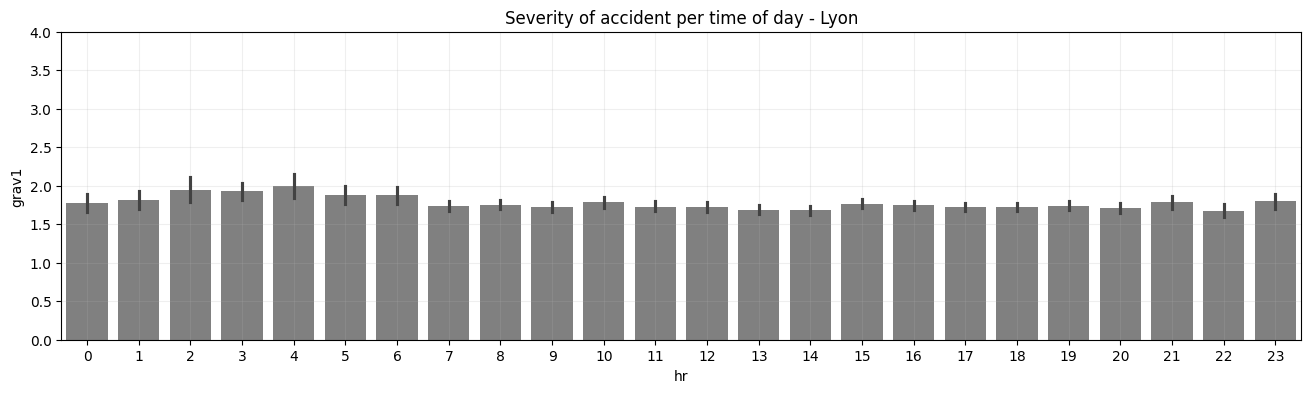

In [81]:
plt.figure(figsize=(16,4))
sns.barplot(data=time_lyon, x="hr", y="grav1",color="gray")
plt.grid(True, alpha=0.2)
plt.ylim(0,4)
plt.title("Severity of accident per time of day - Lyon")

Text(0.5, 1.0, 'Severity of accident per time of day - Paris')

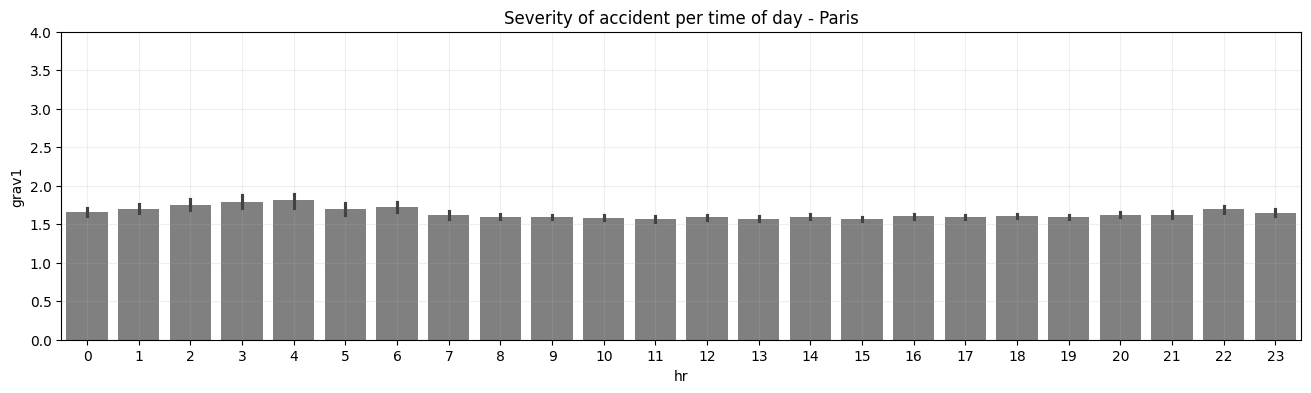

In [82]:
plt.figure(figsize=(16,4))
sns.barplot(data=time_paris, x="hr", y="grav1", color="gray")
plt.grid(True, alpha=0.2)
plt.ylim(0,4)
plt.title("Severity of accident per time of day - Paris")

In [83]:
df = df_time.copy()

df["hour"] = (df["hrmn"] // 100).astype(int)

bins = [0, 6, 10, 14, 18, 22, 24]
labels = ["0-6h", "6-10h", "10-14h", "14-18h", "18-22h", "22-24h"]
df["time_slot"] = pd.cut(df["hour"], bins=bins, labels=labels, right=False, include_lowest=True)

df["severity"] = df["grav"].apply(lambda x: "minor" if x in [1, 4] else "major")

city_map = {750: "Paris", 690: "Lyon"}
df = df[df["dep"].isin([750, 690])].copy()
df["city"] = df["dep"].map(city_map)

df

,Num_Acc,hrmn,lum,grav,dep,hr,grav1,hour,time_slot,severity,city
4062,201700001776,1730,5,1,690,1730,1,17,14-18h,minor,Lyon
4063,201700001776,1730,5,4,690,1730,2,17,14-18h,minor,Lyon
4064,201700001776,1730,5,1,690,1730,1,17,14-18h,minor,Lyon
4065,201700001777,300,5,3,690,300,3,3,0-6h,major,Lyon
4066,201700001778,2330,5,3,690,2330,3,23,22-24h,major,Lyon
...,...,...,...,...,...,...,...,...,...,...,...
261487,201800055764,250,5,1,750,250,1,2,0-6h,minor,Paris
261488,201800055765,1215,1,4,750,1215,2,12,10-14h,minor,Paris
261489,201800055765,1215,1,1,750,1215,1,12,10-14h,minor,Paris
261490,201800055766,1740,5,1,750,1740,1,17,14-18h,minor,Paris


In [84]:
grouped = (
    df.groupby(["city", "time_slot", "severity"])
    .size()
    .reset_index(name="count")
)
grouped

,city,time_slot,severity,count
0,Lyon,0-6h,major,190
1,Lyon,0-6h,minor,719
2,Lyon,6-10h,major,348
3,Lyon,6-10h,minor,1573
4,Lyon,10-14h,major,327
5,Lyon,10-14h,minor,1750
6,Lyon,14-18h,major,494
7,Lyon,14-18h,minor,2450
8,Lyon,18-22h,major,403
9,Lyon,18-22h,minor,2032


In [85]:
totals = df.groupby(["city", "time_slot"]).size().reset_index(name="total")
grouped = grouped.merge(totals, on=["city", "time_slot"])
grouped["proportion"] = grouped["count"] / grouped["total"]

major_df = grouped[grouped["severity"] == "major"]
paris_df = major_df[major_df["city"] == "Paris"]
lyon_df  = major_df[major_df["city"] == "Lyon"]

major_df


,city,time_slot,severity,count,total,proportion
0,Lyon,0-6h,major,190,909,0.209021
2,Lyon,6-10h,major,348,1921,0.181156
4,Lyon,10-14h,major,327,2077,0.157439
6,Lyon,14-18h,major,494,2944,0.167799
8,Lyon,18-22h,major,403,2435,0.165503
10,Lyon,22-24h,major,79,501,0.157685
12,Paris,0-6h,major,160,2050,0.078049
14,Paris,6-10h,major,187,3687,0.050719
16,Paris,10-14h,major,186,4885,0.038076
18,Paris,14-18h,major,271,5883,0.046065


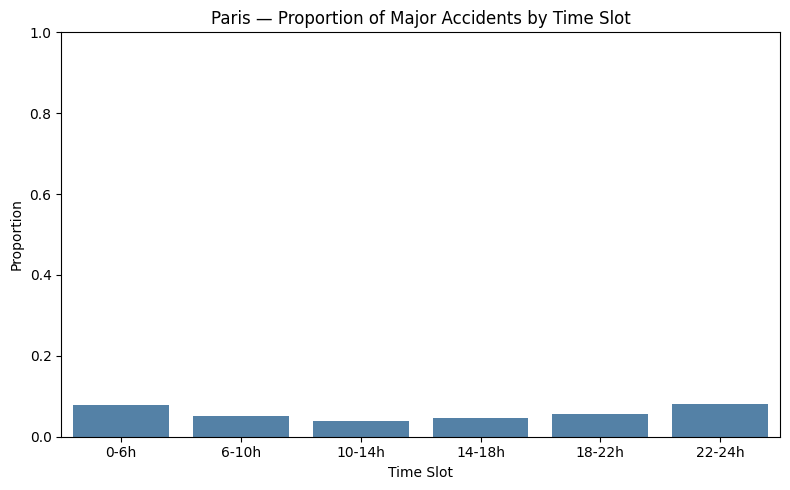

In [86]:
fig, ax = plt.subplots(figsize=(8, 5))
sns.barplot(data=paris_df, x="time_slot", y="proportion", ax=ax, color="steelblue")
ax.set_title("Paris — Proportion of Major Accidents by Time Slot")
ax.set_xlabel("Time Slot")
ax.set_ylabel("Proportion")
ax.set_ylim(0, 1)
plt.tight_layout()
plt.show()

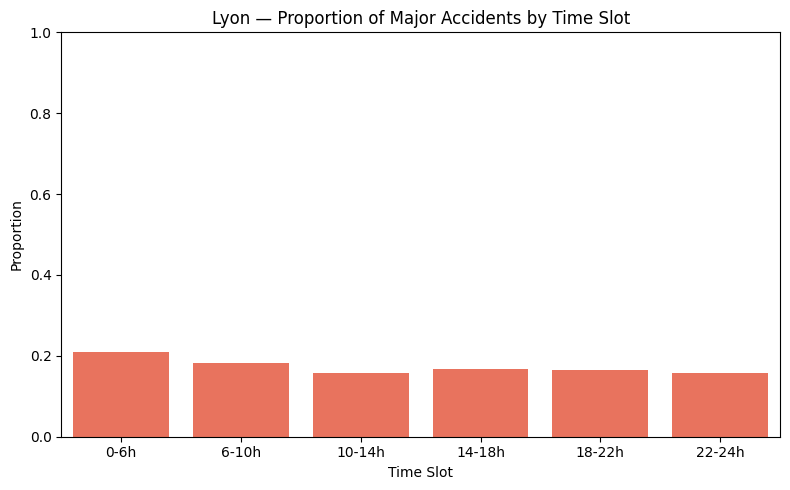

In [87]:
fig, ax = plt.subplots(figsize=(8, 5))
sns.barplot(data=lyon_df, x="time_slot", y="proportion", ax=ax, color="tomato")
ax.set_title("Lyon — Proportion of Major Accidents by Time Slot")
ax.set_xlabel("Time Slot")
ax.set_ylabel("Proportion")
ax.set_ylim(0, 1)
plt.tight_layout()
plt.show()

In [88]:
paris_x = paris_df["time_slot"].astype(str).tolist()
paris_y = paris_df["proportion"].tolist()
lyon_x  = lyon_df["time_slot"].astype(str).tolist()
lyon_y  = lyon_df["proportion"].tolist()

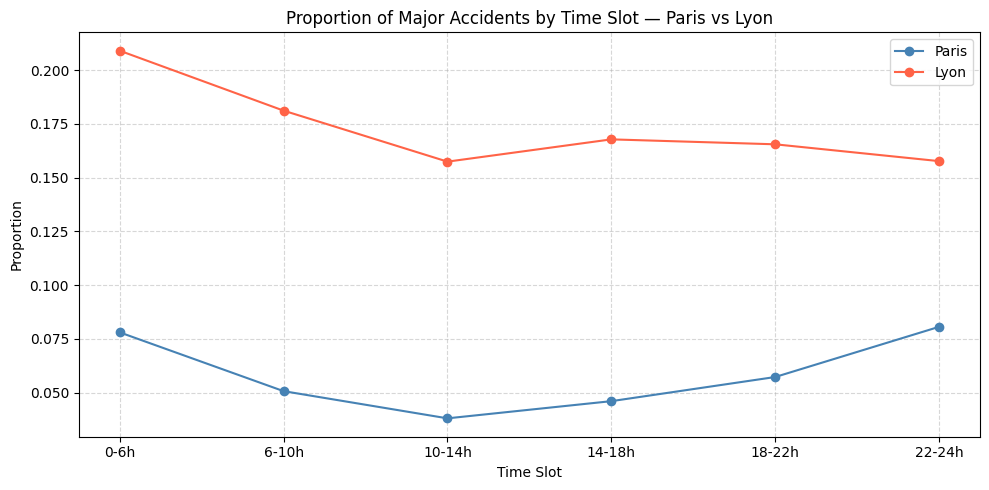

In [89]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(paris_x, paris_y, marker="o", label="Paris", color="steelblue")
ax.plot(lyon_x,  lyon_y,  marker="o", label="Lyon",  color="tomato")
ax.set_title("Proportion of Major Accidents by Time Slot — Paris vs Lyon")
ax.set_xlabel("Time Slot")
ax.set_ylabel("Proportion")
ax.legend()
ax.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

In [90]:
paris_raw = df[df["city"] == "Paris"]
lyon_raw  = df[df["city"] == "Lyon"]

slot_0_6   = df[df["time_slot"] == "0-6h"]
slot_6_10  = df[df["time_slot"] == "6-10h"]
slot_10_14 = df[df["time_slot"] == "10-14h"]
slot_14_18 = df[df["time_slot"] == "14-18h"]
slot_18_22 = df[df["time_slot"] == "18-22h"]
slot_22_24 = df[df["time_slot"] == "22-24h"]

for slot_df, slot_name in [
    (slot_0_6,   "0-6h"),
    (slot_6_10,  "6-10h"),
    (slot_10_14, "10-14h"),
    (slot_14_18, "14-18h"),
    (slot_18_22, "18-22h"),
    (slot_22_24, "22-24h")
]:
    contingency = pd.crosstab(slot_df["city"], slot_df["severity"])
    chi2, p, _, _ = st.chi2_contingency(contingency)
    sig = "yes" if p < 0.05 else "no"
    print(f"{slot_name:<10} / {chi2:>8.3f} / {p:>12} / {sig:>8}")

0-6h       /  102.329 / 4.703613272429472e-24 /      yes
6-10h      /  247.486 / 9.17350139068521e-56 /      yes
10-14h     /  302.457 / 9.604547977861177e-68 /      yes
14-18h     /  365.805 / 1.533541748187253e-81 /      yes
18-22h     /  240.379 / 3.251233828714082e-54 /      yes
22-24h     /   23.799 / 1.0692429247434825e-06 /      yes
